# Default Risk Analysis

In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

from src import feature_engineering as fe
from src.evaluate import evaluate_classification_metrics
from src import preprocessing as prp

In [3]:
file_path = "../dataset/hdfc_loan_dataset_full_enriched.csv"
df = prp.load_data(file_path)

print(df.head())
print(df.shape)

      Loan_ID       Bank   Customer_Name  Gender Married  Dependents  \
0  HDFC100001  HDFC Bank     Rohan Verma    Male      No           2   
1  HDFC100002  HDFC Bank     Rohan Verma    Male      No           0   
2  HDFC100003  HDFC Bank     Aditya Nair  Female     Yes           0   
3  HDFC100004  HDFC Bank    Ananya Joshi    Male      No           0   
4  HDFC100005  HDFC Bank  Harpreet Singh    Male     Yes           3   

  Education Employment_Status  Applicant_Income  Coapplicant_Income  ...  \
0  Graduate          Salaried             56976                   0  ...   
1  Graduate        Unemployed              1856                   0  ...   
2  Graduate          Salaried             64553                   0  ...   
3  Graduate          Salaried             88450                   0  ...   
4  Graduate     Self-Employed              9539                   0  ...   

   Loan_to_Annual_Income  Customer_Sentiment  Religion        State      City  \
0                 11.747     

In [4]:
# Remove Duplicates
df = prp.remove_duplicates(df)

Duplicate Rows: 0


In [5]:
# Create target variable
df = fe.create_high_risk(df)

In [6]:
# Check Risk distribution
print(df["High_Risk"].value_counts())

High_Risk
0    906
1     94
Name: count, dtype: int64


In [7]:
# feature selection
features = [
    'Debt_to_Income_Ratio', 'Existing_EMIs', 'CIBIL_Score',
    'Employment_Length_Years', 'Annual_Household_Income',
    'Loan_to_Annual_Income', 'Applicant_Income', 'Coapplicant_Income',
    'Loan_Amount', 'Credit_History', 'Occupation',
    'Employment_Status', 'Education', 'Property_Area',
    'Customer_Sentiment', 'State'  
]

target = "High_Risk"

X = df[features]
y = df[target]

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Debt_to_Income_Ratio     1000 non-null   float64
 1   Existing_EMIs            1000 non-null   int64  
 2   CIBIL_Score              1000 non-null   int64  
 3   Employment_Length_Years  1000 non-null   int64  
 4   Annual_Household_Income  1000 non-null   int64  
 5   Loan_to_Annual_Income    1000 non-null   float64
 6   Applicant_Income         1000 non-null   int64  
 7   Coapplicant_Income       1000 non-null   int64  
 8   Loan_Amount              1000 non-null   int64  
 9   Credit_History           1000 non-null   int64  
 10  Occupation               1000 non-null   str    
 11  Employment_Status        1000 non-null   str    
 12  Education                1000 non-null   str    
 13  Property_Area            1000 non-null   str    
 14  Customer_Sentiment       1000 non-nu

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2,
    stratify=y,
    random_state=45
)

In [15]:
# preprocessing pipeline
numeric_columns = X.select_dtypes(
    include='number'   
).columns

categorical_cols = X.select_dtypes(
    include='str'
).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('import', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder())
])

log_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_columns),
    ('cat', categorical_transformer, categorical_cols)
])

rf_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_columns)
])

# Logistic Regression

Best Logistic Regression Parameters
{'model__C': 10, 'model__solver': 'liblinear'}
Logistic Regression
Accuracy  : 0.9
Precision : 0.46153846153846156
Recall    : 0.3157894736842105
F1 Score  : 0.375
ROC-AUC   : 0.9369002617039837

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       181
           1       0.46      0.32      0.38        19

    accuracy                           0.90       200
   macro avg       0.70      0.64      0.66       200
weighted avg       0.89      0.90      0.89       200



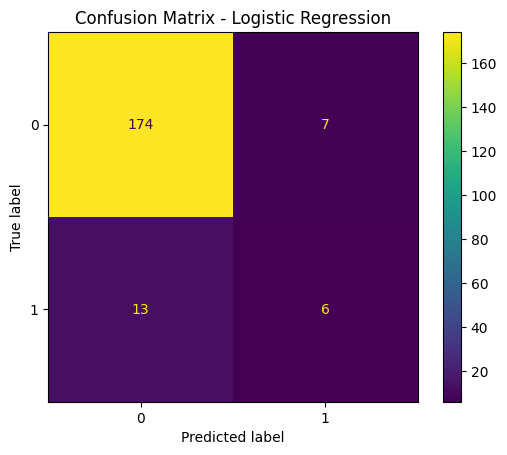

In [10]:
log_model_pipeline = Pipeline([
    ('preprocessor', log_preprocessor),
    (
        'model', 
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

log_params = {
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs']
}

log_grid = GridSearchCV(
    estimator=log_model_pipeline,
    param_grid=log_params,
    cv=StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=43
    ),
    scoring='recall',
    n_jobs=-1
)

log_grid.fit(
    X_train,
    y_train
)

best_log_model = log_grid.best_estimator_

print("Best Logistic Regression Parameters")
print(log_grid.best_params_)
results = []
results.append(
    evaluate_classification_metrics(
        "Logistic Regression",
        best_log_model,
        X_test,
        y_test
    )
)

## Random forest

Best Random Forest Parameters
{'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Random Forest
Accuracy  : 0.96
Precision : 0.7894736842105263
Recall    : 0.7894736842105263
F1 Score  : 0.7894736842105263
ROC-AUC   : 0.981099156731608

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       181
           1       0.79      0.79      0.79        19

    accuracy                           0.96       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.96      0.96      0.96       200



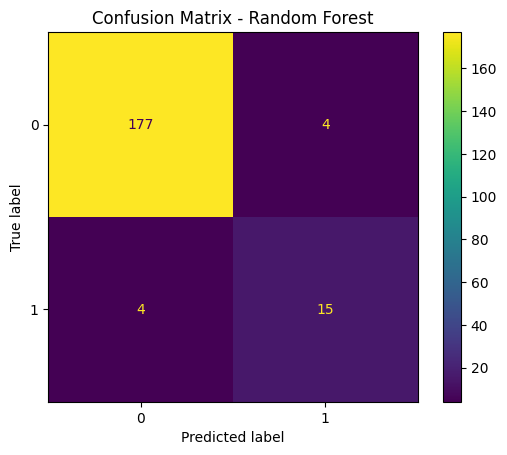

In [11]:
rf_pipeline = Pipeline([
    ('preprocessor', rf_preprocessor),
    (
        'model',
        RandomForestClassifier(
            random_state=42
        )
    )
])

rf_params = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    ),
    scoring='recall',
    n_jobs=-1
)


rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_

print("Best Random Forest Parameters")
print(rf_grid.best_params_)

results.append(
    evaluate_classification_metrics(
        "Random Forest",
        best_rf_model,
        X_test,
        y_test
    )
)


In [12]:
results_df = pd.DataFrame(results)

print("Model Comparison")
print(results_df)

Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression      0.90   0.461538  0.315789  0.375000  0.936900
1        Random Forest      0.96   0.789474  0.789474  0.789474  0.981099


In [13]:
best_model_index = results_df['Recall'].idxmax()

best_model_name = results_df.loc[
    best_model_index,
    'Model'
]

print(f"SBest Model: {best_model_name}")

if best_model_name == 'Logistic Regression':
    final_model = best_log_model

else:
    final_model = best_rf_model

SBest Model: Random Forest


In [14]:
MODEL_PATH = "../models/risk_model.pkl"

joblib.dump(final_model, MODEL_PATH)

print(f"\nModel saved successfully at: {MODEL_PATH}")


Model saved successfully at: ../models/risk_model.pkl
